firedrake:WARNING Subdomain (1,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (2,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (3,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (4,) is empty. This is likely an error. Did you choose the right label?


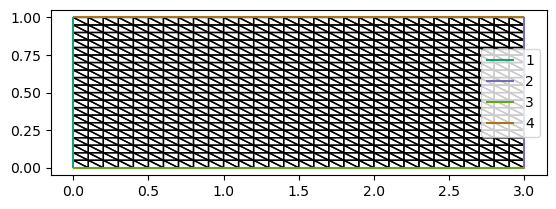

In [132]:
from firedrake import *
import numpy as np
import matplotlib.pyplot as plt

# Rectangle mesh (0,3) x (0,1) with 3*N x N elements
N = 10
mesh = RectangleMesh(3*N, 2*N, 3.0, 1.0, diagonal='left')
fig, ax = plt.subplots()
triplot(mesh, axes=ax)
ax.legend()
ax.set_aspect("equal")


Number of DOF 
 - u    : 5002  
 - p    : 651  
 - total: 5653


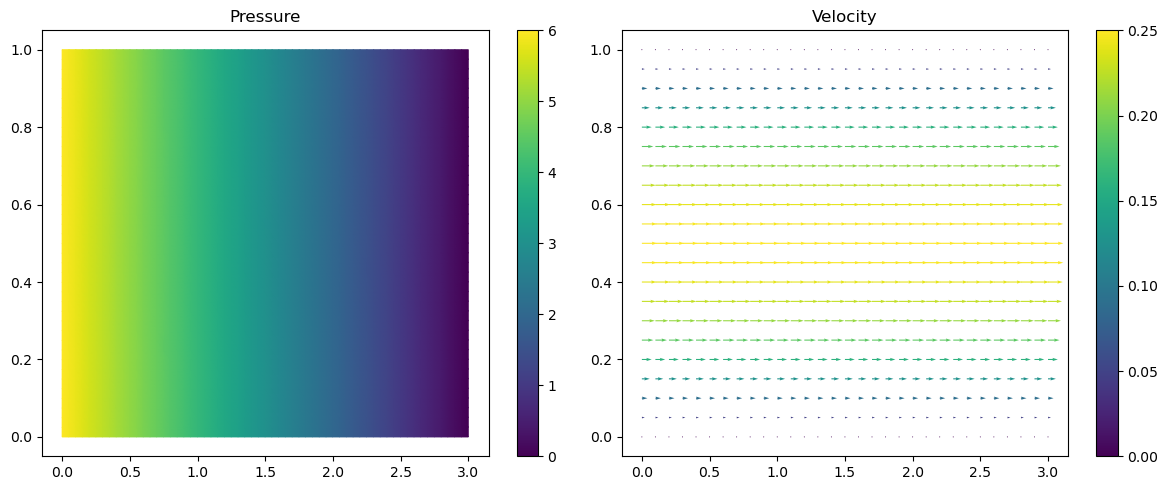

In [141]:
# Stokes problem

# Define function space and trial/test functions for velocity and pressure
V = VectorFunctionSpace(mesh, "P", 2)
Q = FunctionSpace(mesh, "P", 1)
W = MixedFunctionSpace([V, Q])
u, p = TrialFunctions(W)
v, q = TestFunctions(W)
print('\nNumber of DOF \n - u    :',V.dim(),' \n - p    :',Q.dim(),' \n - total:',W.dim())

# Define boundary conditions for velocity (Dirichlet BCs)
x = SpatialCoordinate(mesh)
# Inflow boundary condition: parabolic profile
u_in = as_vector((x[1]*(1-x[1]), 0.))
bc_in = DirichletBC(W.sub(0), u_in, 1) 
# No slip boundary conditions on the walls (bottom and top boundaries)
bc_wall = DirichletBC(W.sub(0), (0., 0.), (3,4))
bcs = [bc_in, bc_wall]

# Define the variational problem
mu0 = 1
n = 0.2
f = Constant((0.0, 0.0))
a = mu0 * inner(grad(u), grad(v)) * dx - p * div(v) * dx + q * div(u) * dx
L = inner(f, v) * dx

# Solve the problem
wh_init = Function(W)
solve(a == L, wh_init, bcs=bcs)


# Plot velocity and pressure
uh, ph = wh_init.subfunctions

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

col0 = tripcolor(ph, axes=ax[0])
fig.colorbar(col0, ax=ax[0])
ax[0].set_title('Pressure')

col1 = quiver(uh, axes=ax[1])
fig.colorbar(col1, ax=ax[1])
ax[1].set_title('Velocity')

plt.tight_layout()

from firedrake.output import VTKFile
outfile = VTKFile("output/130624/solution_" + str(n) + ".pvd")
uh.rename("Velocity")
ph.rename("Pressure")
outfile.write(uh, ph)

# Nonlinear solver: linear variational problem for the Picard iteration
u_old = Function(V)
u_old.assign(uh)
p_old = Function(Q)
p_old.assign(ph)
def nonlinear_iteration_forms(u, v, p, q, mu0, n, f, u_old):
    """
    Nonlinear iteration: solve the Navier-Stokes equations using Picard's iteration or Newton's method.
    """
    # Fixed-point iteration
    a_fp = Constant(2*mu0) * inner(sym(grad(u_old)), sym(grad(u_old)))**((n-1)/2.0) * inner(sym(grad(u)), sym(grad(v))) * dx - div(v) * p * dx + q * div(u) * dx
    L_fp = dot(f, v) * dx
    return a_fp, L_fp
a, L = nonlinear_iteration_forms(u, v, p, q, mu0, n, f, u_old)
wh = Function(W)
problem = LinearVariationalProblem(a, L, wh, bcs=bcs)
param = {'ksp_type': 'preonly', 'pc_type': 'lu', 'pc_factor_mat_solver_type': 'mumps'}
solver =  LinearVariationalSolver(problem, solver_parameters=param)

In [142]:
# Iterative algorithm

maxit = 100
it = 0
tol = 1e-3
err = tol + 1     # >tol in order to enter the loop at the beginning

while it <= maxit and err > tol:
    it += 1

    # solve problem and compute error
    solver.solve()
    uh, ph = wh.subfunctions
    err = errornorm(uh, u_old, 'H1') / norm(u_old, 'H1') + errornorm(ph, p_old, 'L2') / norm(p_old, 'L2')

    print("--------------------------------")
    print(f"Step : {it}")
    print(f"Error: {err}")
    uh.rename("Velocity")
    ph.rename("Pressure")
    outfile.write(uh, ph)

    # update the old solution
    u_old.assign(uh)
    p_old.assign(ph)

print("--------------------------------")

if it <= maxit:
    print('Nonlinear solver converged in', it, 'iterations.')
else:
    print('Nonlinear solver did NOT converge!\nRelative error =', err, 'after', it, 'iterations.')
print("--------------------------------")

--------------------------------
Step : 1
Error: 0.8114775068694906
--------------------------------
Step : 2
Error: 0.1522311254364187
--------------------------------
Step : 3
Error: 0.09429632017997124
--------------------------------
Step : 4
Error: 0.06298379329392961
--------------------------------
Step : 5
Error: 0.04429651003037044
--------------------------------
Step : 6
Error: 0.032099161567227225
--------------------------------
Step : 7
Error: 0.023719564534721814
--------------------------------
Step : 8
Error: 0.01778545003831181
--------------------------------
Step : 9
Error: 0.013487900957106487
--------------------------------
Step : 10
Error: 0.010318259877032764
--------------------------------
Step : 11
Error: 0.007946212003583131
--------------------------------
Step : 12
Error: 0.006150784112621069
--------------------------------
Step : 13
Error: 0.004779781303404494
--------------------------------
Step : 14
Error: 0.003725744038972276
-----------------------

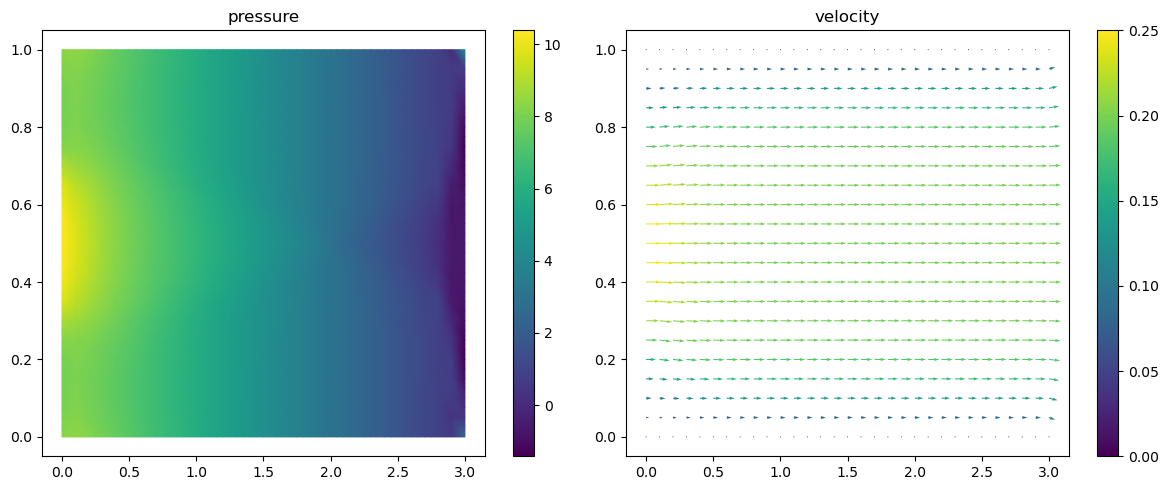

In [143]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

col0 = tripcolor(ph, axes=ax[0])
fig.colorbar(col0, ax=ax[0])
ax[0].set_title('pressure')

col1 = quiver(uh, axes=ax[1])
fig.colorbar(col1, ax=ax[1])
ax[1].set_title('velocity')

plt.tight_layout()

In [144]:
normal = FacetNormal(mesh)
D = sym(grad(uh))
drag = assemble(- Constant(2*mu0) * inner(D, D)**((n-1)/2.0) * inner(dot(D, normal), Constant((1.0, 0.0)))* (ds(3) + ds(4)))
print("Drag force on the cylinder for n =", n, ":", drag)

Drag force on the cylinder for n = 0.2 : 9.062287620343955
